# Sin-wave Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
def normalize(
    array: np.array,
    min_: float = None,
    max_: float = None
):
    if len(np.unique(array)) == 1:
        value = np.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return np.ones_like(array) * norm_value
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()
    return (array - min_) / (max_ - min_)


def denormalize(
    normalized_array: np.array,
    min_: float,
    max_: float
) -> np.array:
    return normalized_array * (max_ - min_) + min_

## Generate

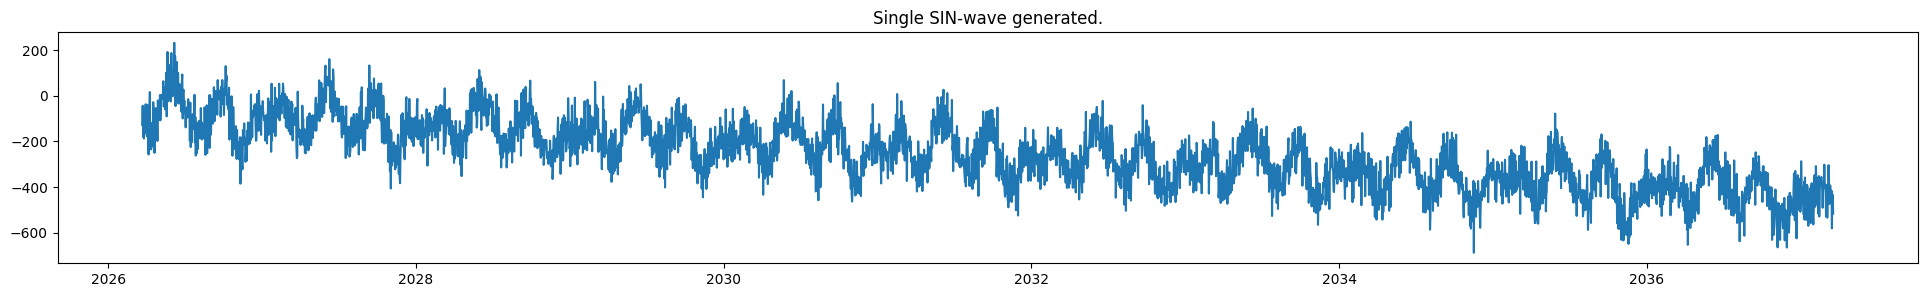

In [3]:
def generate_wave(
    n_years=None,
    frequency=2 * np.pi / 365.25,
    beta=1,
    variation=False,
    elevation_power=0,
    amplitude_change_power=0,
    noise_level=1e-1
):
    if n_years is None:
        n_years = np.random.randint(1, 15)
    amplitude = np.random.randint(-100, 100)
    phase_shift = np.random.randint(-180, 180)
    period_starts = pd.Timestamp('now')
    a = np.random.randint(-500, 500) / (n_years * 365.25)
    b = np.random.randint(-100, 100)
    duration_days = int(365 * n_years)
    period_ends = period_starts + pd.Timedelta(days=duration_days)
    x = np.linspace(1, duration_days, duration_days)
    if not variation:
        y = amplitude * np.sin(frequency * x + phase_shift)
    else:
        y = amplitude * (x ** amplitude_change_power) * np.sin(x ** beta * frequency + phase_shift)
    y += a * x + b
    y += -1 + x ** elevation_power
    if noise_level:
        min_, max_ = y.min(), y.max()
        y = normalize(y, min_, max_)
        y += noise_level * np.random.randn(len(y))
        y = denormalize(y, min_, max_)
    x_date = pd.date_range(period_starts, period_ends, freq='D')[:-1]
    return x, y, x_date


def generate_multiwave_harmonic(
    N,
    n_years=None,
    beta=1,
    variation=True,
    elevation_power=0,
    amplitude_change_power=0,
    noise_level=1e-1
):
    if n_years is None:
        n_years = np.random.randint(1, 15)
    period_starts = pd.Timestamp('now')
    duration_days = int(365 * n_years)
    period_ends = period_starts + pd.Timedelta(days=duration_days)
    x_date = pd.date_range(period_starts, period_ends, freq='D')[:-1]
    x = np.linspace(1, duration_days, duration_days)
    a = np.random.randint(-500, 500) / (n_years * 365.25)
    b = np.random.randint(-100, 100)
    waves = {}
    for i in range(N):
        frequency = 2 * np.pi / 365.25 * (i + 1)
        amplitude = np.random.randint(-100, 100)
        phase_shift = np.random.randint(-180, 180)
        if not variation:
            waves[i] = amplitude * np.sin(frequency * X + phase_shift)
        else:
            waves[i] = amplitude * (x ** amplitude_change_power) * np.sin(x ** beta * frequency + phase_shift)
    y = np.sum(list(waves.values()), axis=0)
    linear_component = a * x + b
    exponential_component = x ** elevation_power
    y = y + linear_component + exponential_component
    if noise_level:
        min_, max_ = y.min(), y.max()
        y = normalize(y, min_, max_)
        y = y + noise_level * np.random.randn(len(y))
        y = denormalize(y, min_, max_)
    return x, y, x_date, waves, linear_component, exponential_component

x, y, x_date, waves, linear_component, exponential_component = generate_multiwave_harmonic(5)
# x, y, x_date = generate_wave(n_years=None)
plt.figure(figsize=(24, 3))
plt.plot(x_date, y)
plt.title(f'Single SIN-wave generated.')# {amplitude=:.2f}, {frequency=:.2f}, {phase_shift=:.2f}')
plt.show()

# Torch

## Definitions

In [4]:
import torch
import torch.nn.functional as F
import tqdm
device = 'cuda'

In [5]:
def torch_least_squares_simple(x, y) -> tuple:
    '''
    Both x and y are 1D arrays
    returns (a, b) from y = ax + b
    '''
    n = len(x)
    sum_x = torch.sum(x)
    sum_y = torch.sum(y)
    sum_xy = torch.sum(x * y)
    sum_x2 = torch.sum(x ** 2)
    denominator = n * sum_x2 - sum_x ** 2
    a = (n * sum_xy - sum_x * sum_y) / denominator
    b = (sum_y * sum_x2 - sum_x * sum_xy) / denominator
    return a, b

   
def normalize_torch(
    array: torch.Tensor,
    min_: float = None,
    max_: float = None
):
    if len(torch.unique(array)) == 1:
        value = torch.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return torch.ones_like(array) * norm_value    
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()        
    return (array - min_) / (max_ - min_)


def denormalize_torch(
    normalized_array: torch.Tensor,
    min_: float,
    max_: float
) -> torch.Tensor:
    return normalized_array * (max_ - min_) + min_


def freeze_parameters(model, whitelist):
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if name in whitelist:
            param.requires_grad = True


def get_max_gap_bool_vec(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.max() if runs.numel() > 0 else 0


def get_median_gap_bool_vec(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.median() if runs.numel() > 0 else 0


def rolling_mean_centered_unbiased(x, window):
    assert window % 2 == 1
    x = x.unsqueeze(0).unsqueeze(0)  # (1,1,N)
    kernel = torch.ones(1, 1, window, device=x.device, dtype=x.dtype)
    pad = window // 2
    sums = F.conv1d(x, kernel, padding=pad)
    counts = F.conv1d(torch.ones_like(x), kernel, padding=pad)
    return (sums / counts).squeeze()


def find_intersections(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    a = x[:-1]
    b = x[1:]
    mask = ((a <= t) & (t <= b)) | ((b <= t) & (t <= a))
    return torch.nonzero(mask, as_tuple=True)[0]


def get_max_gap(intersections, len_):
    device = intersections.device      
    padded = torch.cat([torch.tensor([0], device=device), intersections, torch.tensor([len_-1], device=device)])
    return padded.diff().max()


def get_median_gap(intersections):
    return intersections.diff().median()


def get_init_sin_params(
    x, y_hornorm, rolling_window: int = None,
    frequency_allowance: float = 0.01,
    amplitude_allowance: float = 0.01
):
    if rolling_window is not None:
        assert rolling_window % 2, 'Window must be odd'
        y_hornorm_rolling = rolling_mean_centered_unbiased(y_hornorm, rolling_window)
    else:
        y_hornorm_rolling = y_hornorm    
    n = y_hornorm.numel()
    intersections = find_intersections(y_hornorm_rolling, 0)
    frequency = torch.pi / get_max_gap(intersections, n)
    phase = frequency * intersections[0]
    x_angular = frequency * x
    pred = torch.sin(x_angular - phase)
    sign = torch.sign((y_hornorm_rolling * pred).sum())
    # phase = phase + (sign < 0) * torch.pi
    min_amplitude = (y_hornorm_rolling.max() - y_hornorm_rolling.min()) / 2
    max_amplitude = (y_hornorm.max() - y_hornorm.min()) / 2
    return {
        'frequency_allowance': frequency_allowance,
        'amplitude_allowance': amplitude_allowance,
        'middle_density': torch.tensor(intersections.shape[0]) / n,
        'min_frequency': frequency,
        'max_frequency': torch.pi / get_median_gap(intersections),
        'min_amplitude': min_amplitude,
        'max_amplitude': max_amplitude,
        'amplitude': (max_amplitude + min_amplitude) / 2,           
        'phase': phase
    }


def compute_density_loss(sin_wave, sinwave_params):
    '''
    It is assumed that the wave is horizontal -0.5 to 0.5 normalized
    '''
    middle_density_target = sinwave_params['middle_density']
    n = sin_wave.numel()
    intersections = find_intersections(sin_wave, 0)
    middle_density_hat = torch.tensor(intersections.shape[0]) / n
    density_loss = (middle_density_hat - middle_density_target) ** 2
    return density_loss


def train_sinenn(
    sinenn, x, y, sinwave_params: dict,
    steps_phase: int = 50,
    steps_freq: int = 100,
    steps_amplitude: int = 25,
    iterations: int = 5,
    learning_rate: float = 0.01    
):
    history = []
    # y_hat = sinenn(x)
    # density_loss = compute_density_loss(y_hat, sinwave_params)
    for iteration in tqdm.tqdm(range(iterations)):
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate)
        freeze_parameters(sinenn, whitelist=['phase'])
        for step in range(steps_phase):
            optimizer.zero_grad()
            y_hat = sinenn(x)
            loss = torch.mean((y_hat - y) ** 2) #+ density_loss
            loss.backward()
            optimizer.step()
            history.append(loss)

        freeze_parameters(sinenn, whitelist=['frequency'])
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate/100)
        for step in range(steps_freq):
            optimizer.zero_grad()
            y_hat = sinenn(x)
            density_loss = compute_density_loss(y_hat, sinwave_params)
            loss = torch.mean((y_hat - y) ** 2) + density_loss
            loss.backward()
            optimizer.step()
            history.append(loss)

    freeze_parameters(sinenn, whitelist=['amplitude'])
    optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate)
    for step in range(steps_amplitude):
        optimizer.zero_grad()
        y_hat = sinenn(x)
        loss = torch.mean((y_hat - y) ** 2) #+ density_loss
        loss.backward()
        optimizer.step()
        history.append(loss)
    return history


def waves_residual_split(x_tensor, y_tensor, num_waves, rolling_window, learning_rate, device, plot=False):
    linlsqr = LinearLSQR(x_tensor, y_tensor, device)
    slope, intercept = linlsqr.slope, linlsqr.intercept
    line = linlsqr(x_tensor)
    y_horizontal = y_tensor - line
    params = {
        'intercept': intercept,
        'slope': slope,
        'waves': []
    }
    y_hornorm = y_horizontal
    for wave_number in range(num_waves):
        min_, max_ = y_hornorm.min(), y_hornorm.max()
        y_hornorm = normalize_torch(y_hornorm, min_, max_) - 0.5
        sinwave_params = get_init_sin_params(x_tensor, y_hornorm, rolling_window=rolling_window)
        sinenn = SineNN(sinwave_params).to(device)
        if plot:
            sin_wave_untrained = sinenn(x_tensor)
            loss_untrained = (y_hornorm - sin_wave_untrained).abs().mean().item()
        history = train_sinenn(sinenn, x_tensor, y_hornorm, sinwave_params, learning_rate=learning_rate)
        with torch.no_grad():
            sin_wave = sinenn(x_tensor)
        loss_trained = (y_hornorm - sin_wave).abs().mean().item()  
        y_hornorm -= sin_wave
        params['waves'].append(
            {
                'min': min_,
                'max': max_,
                'amplitude_bound': sinenn.amplitude_bound,
                'frequency_bound': sinenn.frequency_bound,
                'phase': sinenn.phase
            }
        )
        if plot:
            plt.figure(figsize=(30, 1))
            plt.plot(x_tensor.cpu(), y_hornorm.cpu())
            plt.plot(x_tensor.cpu(), sin_wave_untrained.detach().cpu())
            plt.plot(x_tensor.cpu(), sin_wave.detach().cpu())
            loss_diff = 100 * (loss_trained - loss_untrained) / np.abs(loss_untrained)
            plt.title(f'{loss_untrained=:.2f}, {loss_trained=:.2f}, {loss_diff:.2f}%')
            plt.show()
    residual = y_hornorm
    waves_params = params
    return waves_params, residual


def reconstruct_y(x_tensor, residual, params): 
    for wave in params['waves'][::-1]:
        min_ = wave['min']
        max_ = wave['max']
        amplitude = wave['amplitude_bound']
        freq = wave['frequency_bound']
        phase = wave['phase']
        sin_wave_hornorm = amplitude * torch.sin(freq * x_tensor - phase)
        residual_normalized = residual + sin_wave_hornorm
        residual = denormalize_torch(residual_normalized + 0.5, min_, max_)        
    slope = params['slope']
    intercept = params['intercept']
    line = slope * x_tensor + intercept
    return residual + line

In [6]:
class LinearLSQR(torch.nn.Module):
    def __init__(self, x, y, device):
        super().__init__()
        self.slope, self.intercept = torch_least_squares_simple(x, y)
        self.slope.to(device)
        self.intercept.to(device)

    def forward(self, x):
        return self.slope * x + self.intercept


class SineNN(torch.nn.Module):
    def __init__(self, params):
        super().__init__()
        self.frequency_allowance = params['frequency_allowance']
        self.amplitude_allowance = params['amplitude_allowance']
        self.middle_density = params['middle_density'] 
        self.min_amplitude = params['min_amplitude']
        self.max_amplitude = params['max_amplitude']
        self.min_frequency = params['min_frequency']
        self.max_frequency = params['max_frequency']
        self.amplitude = torch.nn.Parameter(params['amplitude'])
        self.frequency = torch.nn.Parameter((self.min_frequency + self.max_frequency) / 2)
        self.phase = torch.nn.Parameter(params['phase'])

    def forward(self, x):
        self.frequency_bound = torch.clamp(
            self.frequency,
            self.min_frequency * (1 - self.frequency_allowance),
            self.max_frequency * (1 + self.frequency_allowance)
        )
        self.amplitude_bound = torch.clamp(
            self.amplitude,
            self.min_amplitude * (1 - self.amplitude_allowance),
            self.max_amplitude
        )
        sin_wave = self.amplitude_bound * torch.sin(self.frequency_bound * x - self.phase)
        return sin_wave


# Bookmark

In [7]:
x_tensor = torch.tensor(x, device=device)
y_tensor = torch.tensor(y, device=device)

linlsqr = LinearLSQR(x_tensor, y_tensor, device)
slope, intercept = linlsqr.slope, linlsqr.intercept
line = linlsqr(x_tensor)
y_horizontal = y_tensor - line
hmin, hmax = y_horizontal.min(), y_horizontal.max()
y_hornorm = normalize_torch(y_horizontal, hmin, hmax) - 0.5

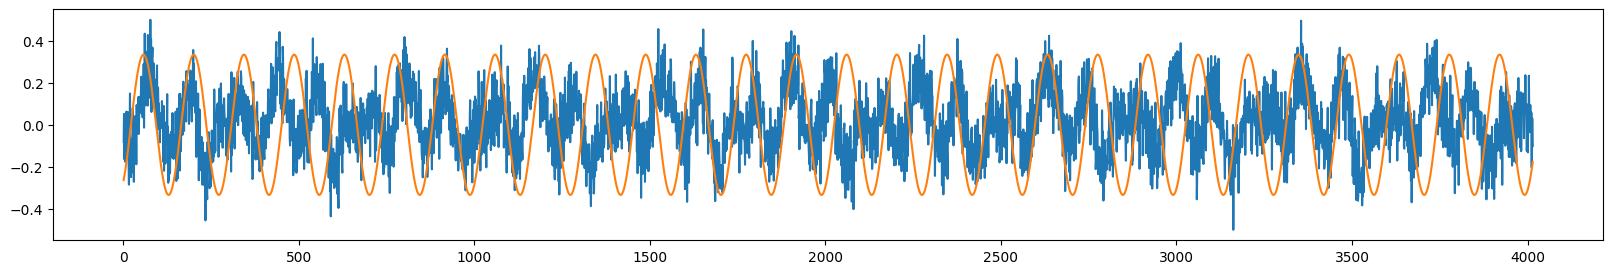

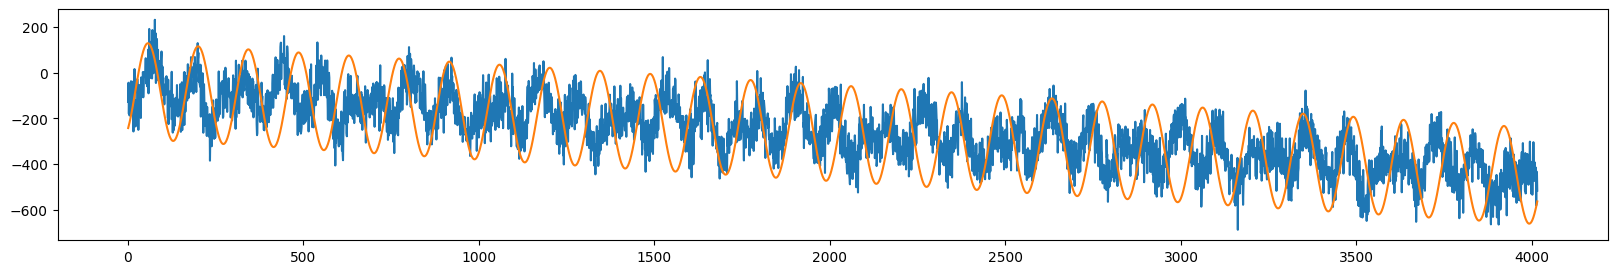

In [8]:
sinwave_params = get_init_sin_params(x_tensor, y_hornorm, rolling_window=61)
sinenn = SineNN(sinwave_params).to(device)
sin_wave_hornorm = sinenn(x_tensor)
sin_wave_horizontal = denormalize_torch(sin_wave_hornorm + 0.5, hmin, hmax)
y_pred = sin_wave_horizontal + line

plt.figure(figsize=(20, 3))
plt.plot(x, y_hornorm.cpu())
plt.plot(x, sin_wave_hornorm.detach().cpu().numpy())
plt.show()

plt.figure(figsize=(20, 3))
plt.plot(x, y)
plt.plot(x, y_pred.detach().cpu().numpy())
plt.show()


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:01<00:00,  2.56it/s]


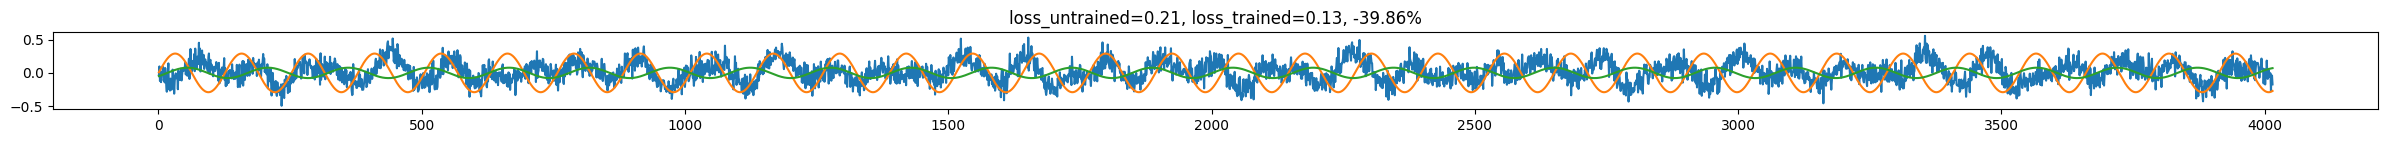

100%|██████████| 5/5 [00:01<00:00,  3.48it/s]


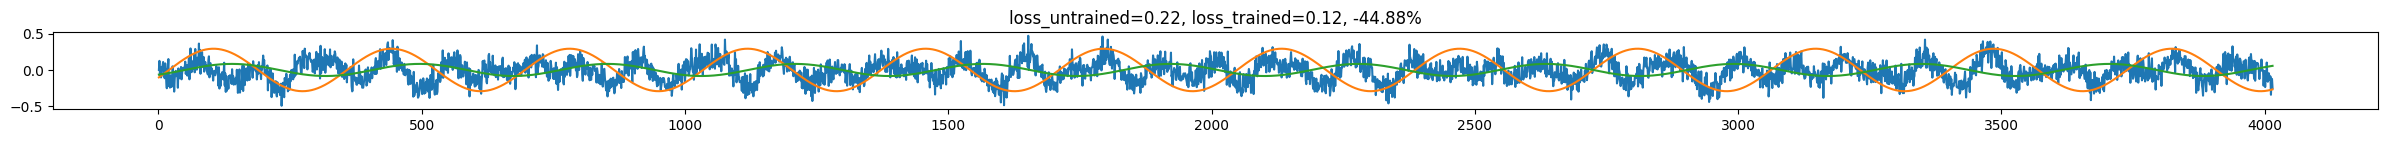

100%|██████████| 5/5 [00:01<00:00,  3.91it/s]


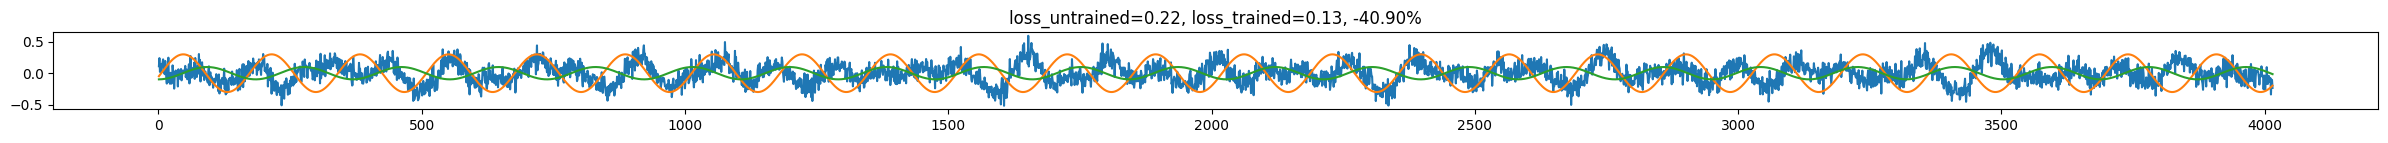

100%|██████████| 5/5 [00:01<00:00,  3.36it/s]


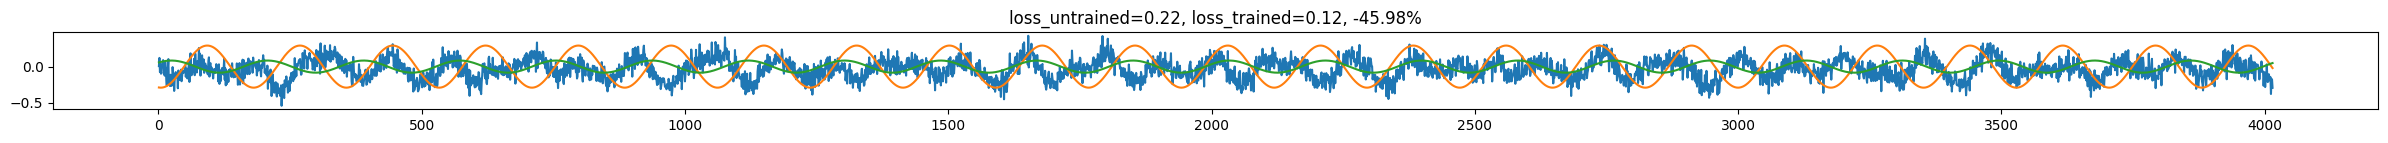

100%|██████████| 5/5 [00:01<00:00,  3.33it/s]


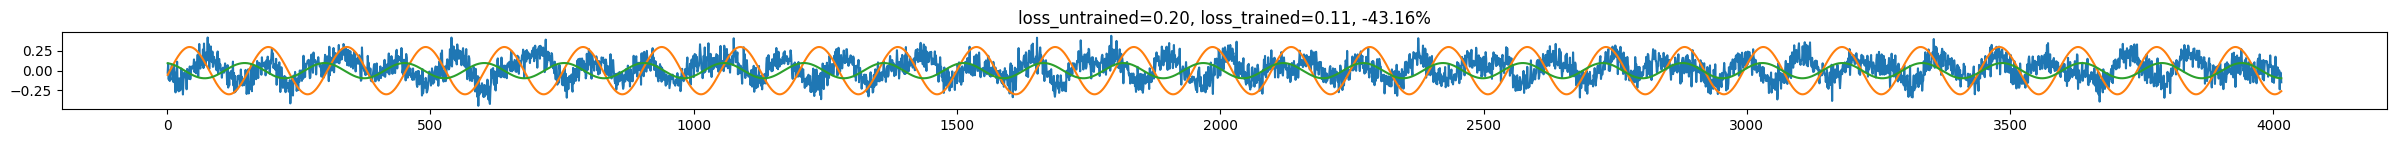

In [9]:
num_waves = 5
rolling_window = 121
learning_rate = 0.1
x_tensor = torch.tensor(x, device=device)
y_tensor = torch.tensor(y, device=device)
waves_params, residual = waves_residual_split(x_tensor, y_tensor, num_waves, rolling_window, learning_rate, device=device, plot=True)
    

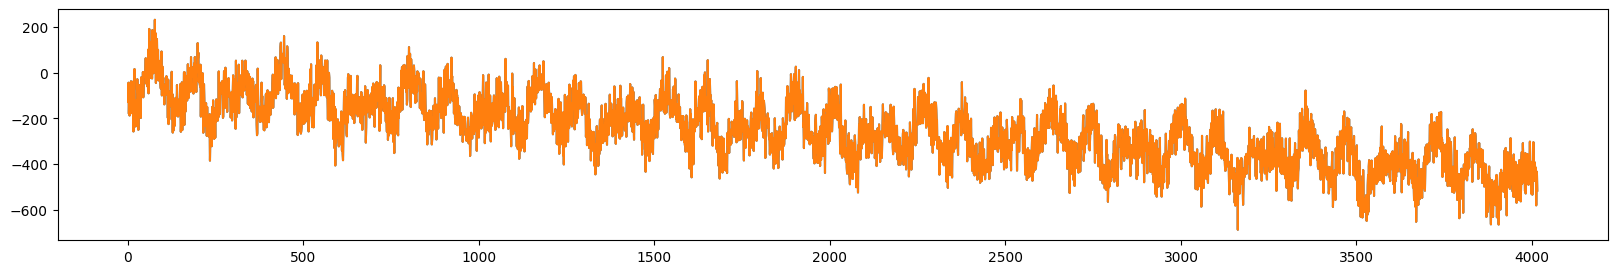

In [10]:
y_pred = reconstruct_y(x_tensor, residual, waves_params)
plt.figure(figsize=(20, 3))
plt.plot(x, y)
plt.plot(x, y_pred.detach().cpu().numpy())
plt.show()

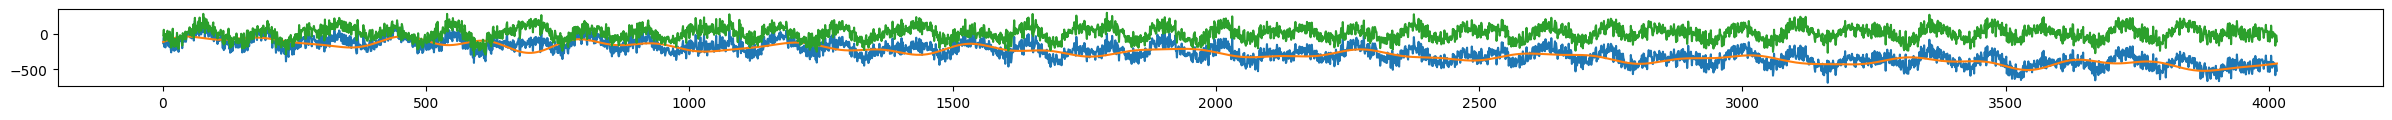

In [11]:
approximation = reconstruct_y(x_tensor, torch.zeros_like(y_tensor), waves_params)
residual = y_tensor - approximation
plt.figure(figsize=(30, 1))
plt.plot(x, y)
plt.plot(x, approximation.detach().cpu().numpy())
plt.plot(x, residual.detach().cpu().numpy())
plt.show()

In [12]:
1/0

ZeroDivisionError: division by zero

## Run

tensor(2190, device='cuda:0')


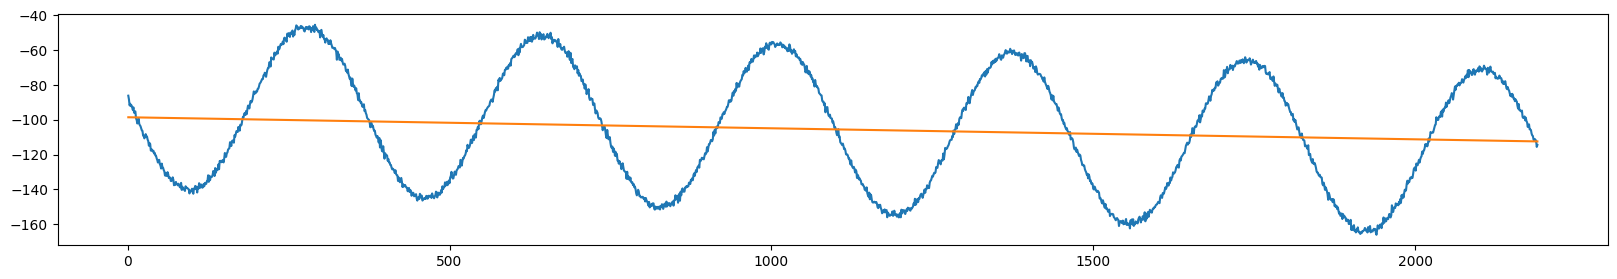

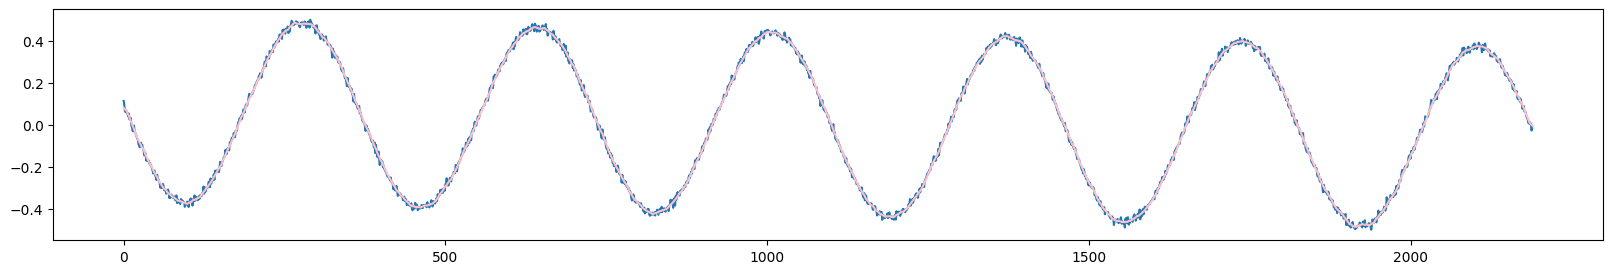

In [ ]:
linlsqr = LinearLSQR(torch.tensor(x, device=device), torch.tensor(y, device=device), device)
line_pred = linlsqr(torch.tensor(x, device=device))
y_horizontal = torch.tensor(y, device=device) - line_pred
y_hornorm = normalize_torch(y_horizontal) - 0.5
y_hornorm_rolling = rolling_mean_centered_unbiased(y_hornorm, 10)

epsilon = 0.01
bool_vec = y_horizontal.abs() <= epsilon
print(get_max_gap_torch(bool_vec))

plt.figure(figsize=(20, 3))
plt.plot(x, y)
plt.plot(x, line_pred.cpu())
plt.show()

plt.figure(figsize=(20, 3))
plt.plot(y_hornorm.cpu())
plt.plot(y_hornorm_rolling.cpu(), color='pink')


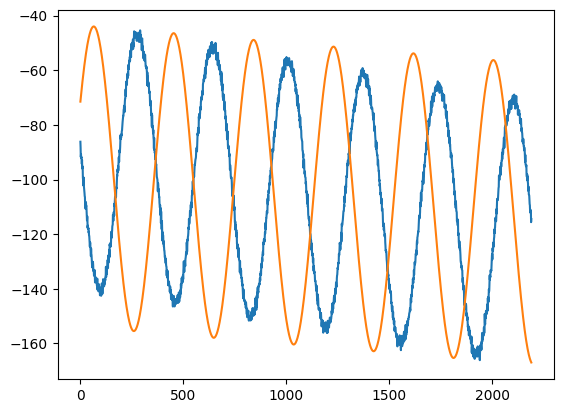

In [ ]:
sinenn = SineNN(torch.tensor(x, device=device), torch.tensor(y, device=device), device, auto_frequency_sensitivity=0.01).to(device)
y_sinenn, middle_density = sinenn(torch.tensor(x, device=device))
y_sinenn = y_sinenn.detach().cpu().numpy()
plt.plot(x, y)
plt.plot(x, y_sinenn)

In [ ]:
sinenn._parameters

{'frequency': Parameter containing:
 tensor(0.0104, device='cuda:0', dtype=torch.float64, requires_grad=True),
 'phase': Parameter containing:
 tensor(0.1693, device='cuda:0')}

100%|██████████| 5/5 [00:01<00:00,  3.03it/s]


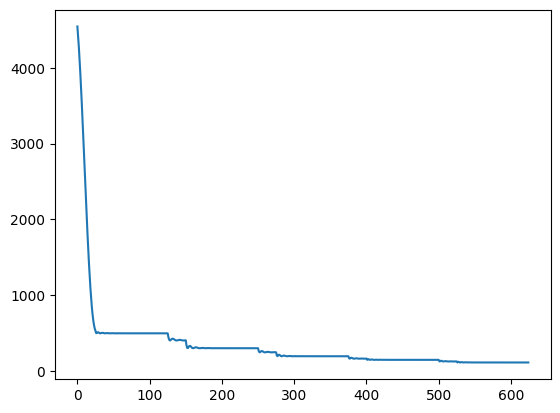

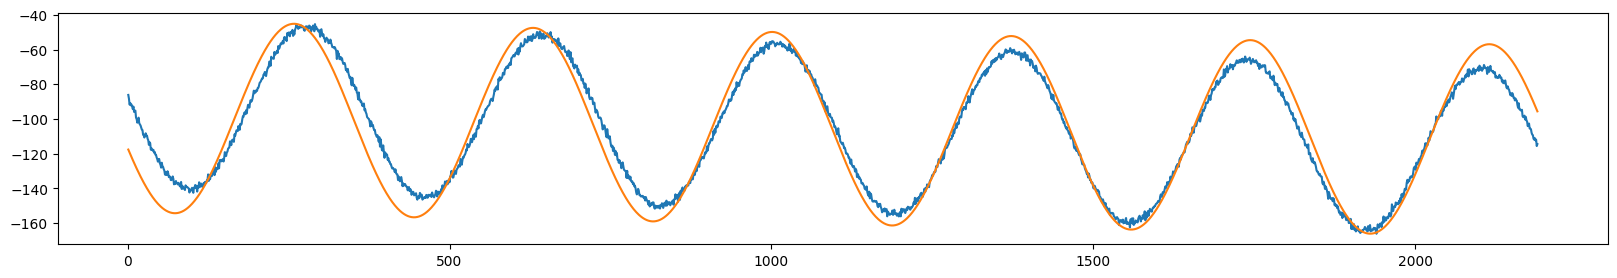

100%|██████████| 5/5 [00:00<00:00, 11.72it/s]


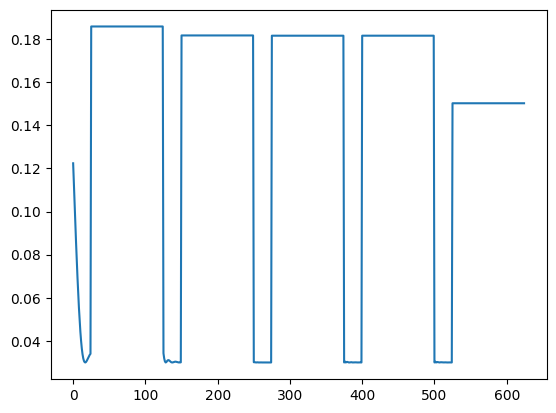

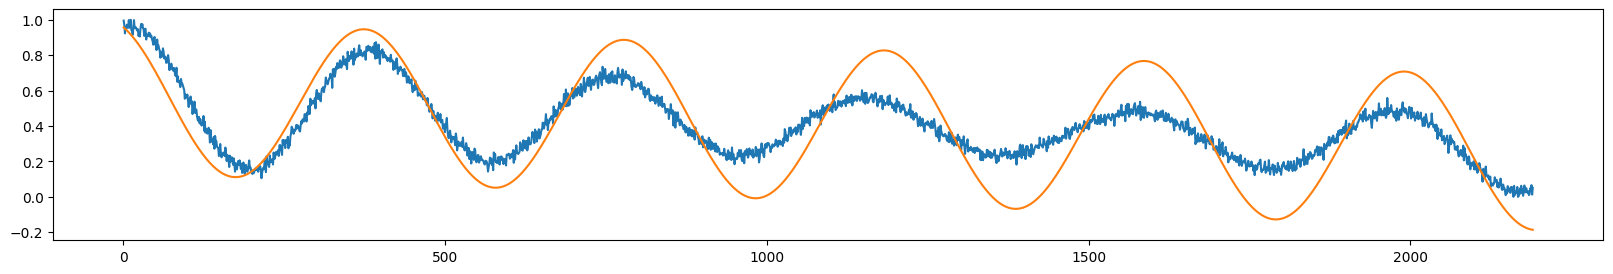

100%|██████████| 5/5 [00:00<00:00, 13.11it/s]


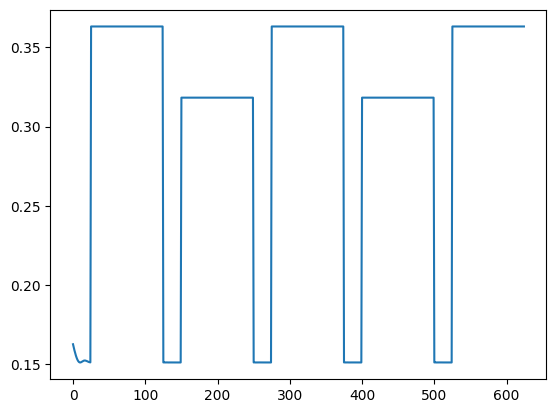

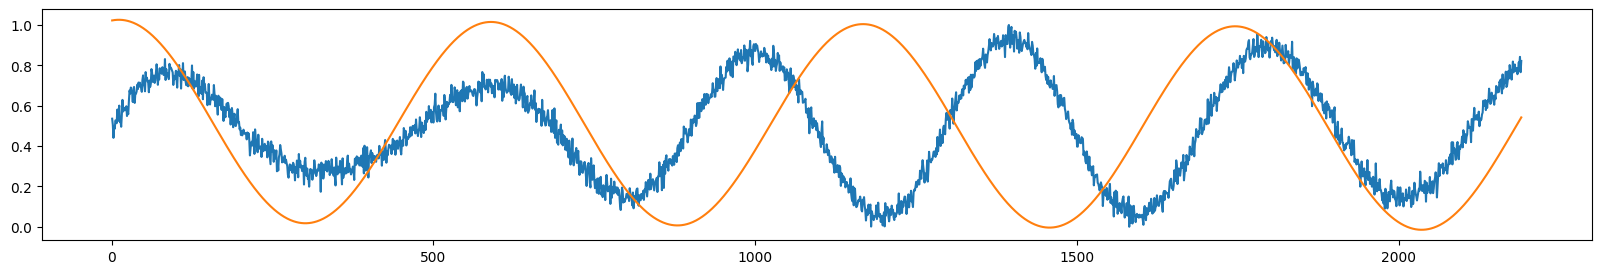

100%|██████████| 5/5 [00:00<00:00, 11.96it/s]


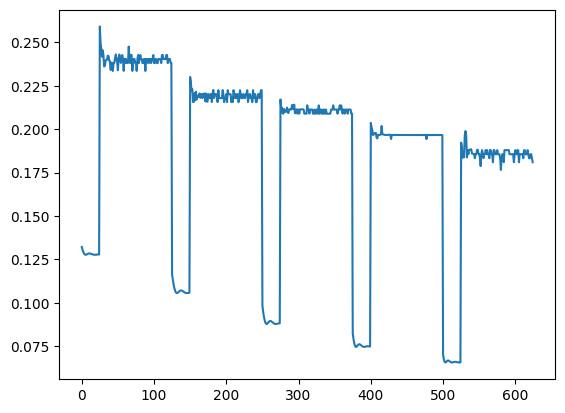

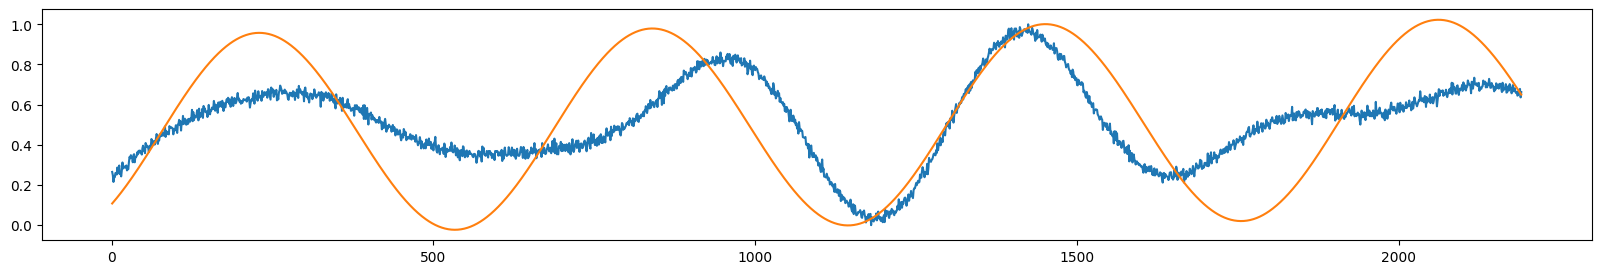

100%|██████████| 5/5 [00:00<00:00, 12.44it/s]


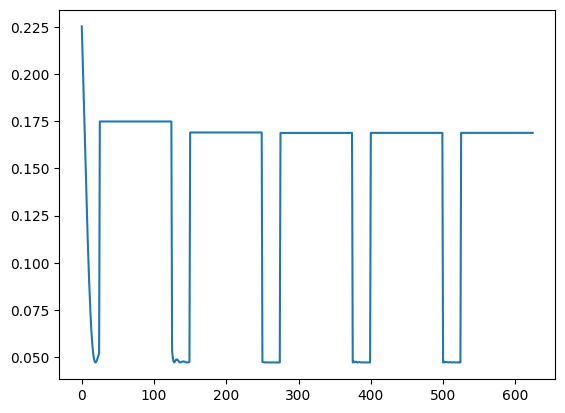

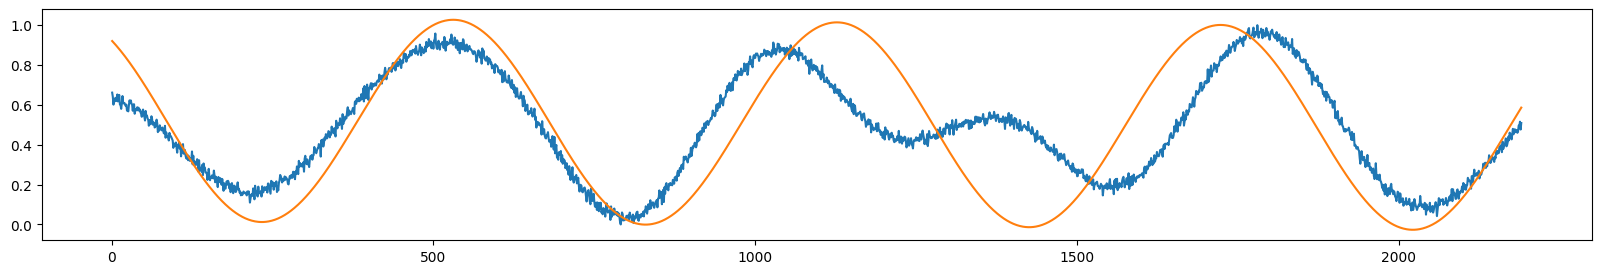

100%|██████████| 5/5 [00:00<00:00, 12.54it/s]


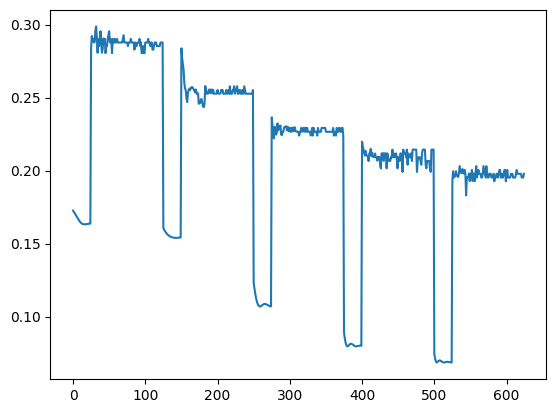

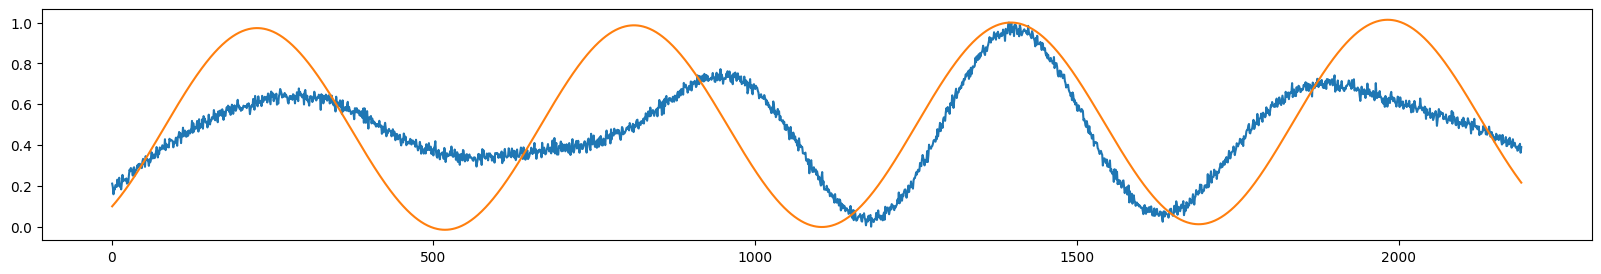

100%|██████████| 5/5 [00:00<00:00, 12.42it/s]


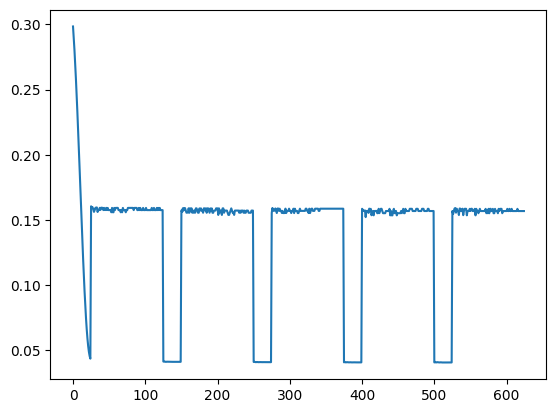

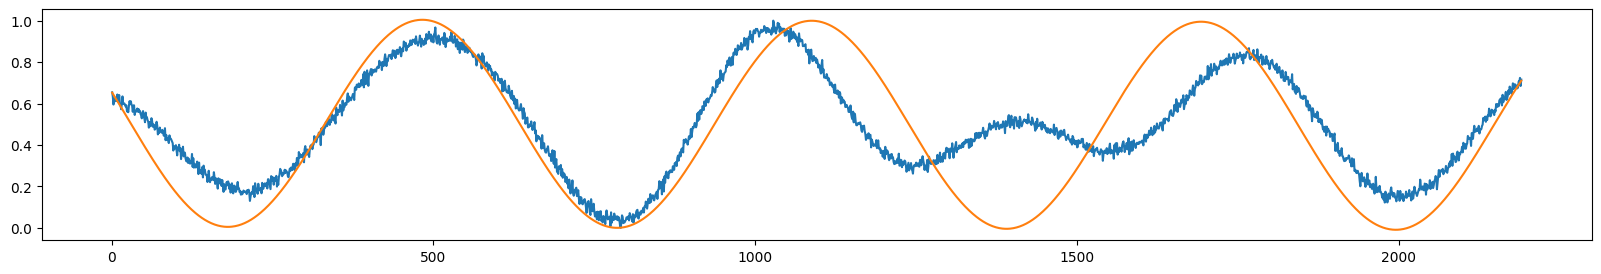

100%|██████████| 5/5 [00:00<00:00, 12.63it/s]


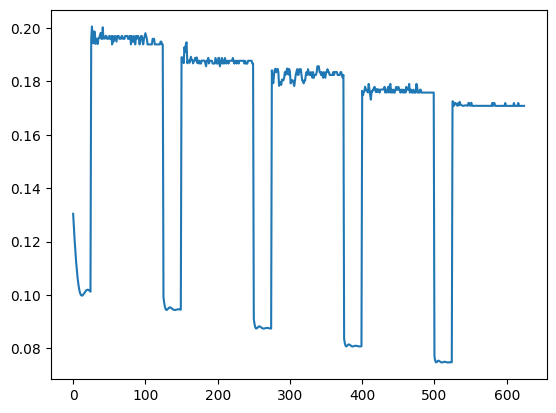

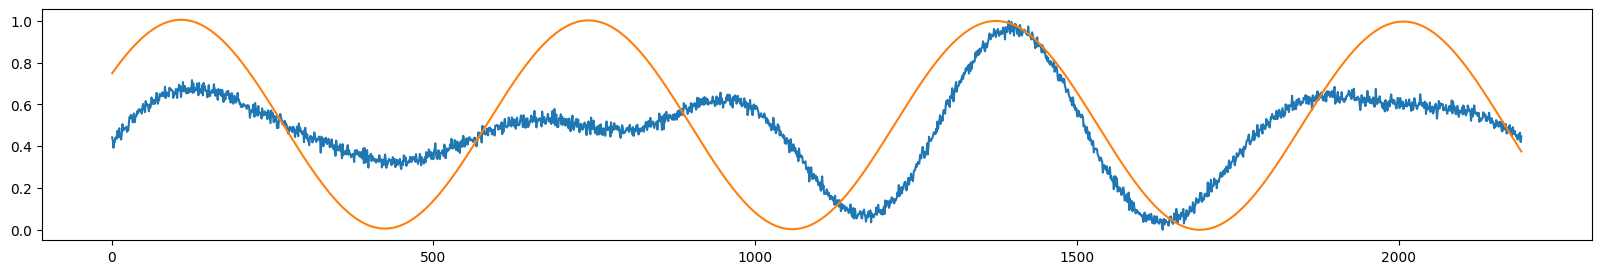

100%|██████████| 5/5 [00:00<00:00, 12.11it/s]


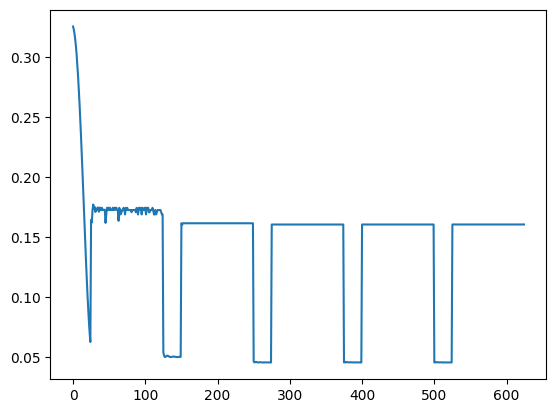

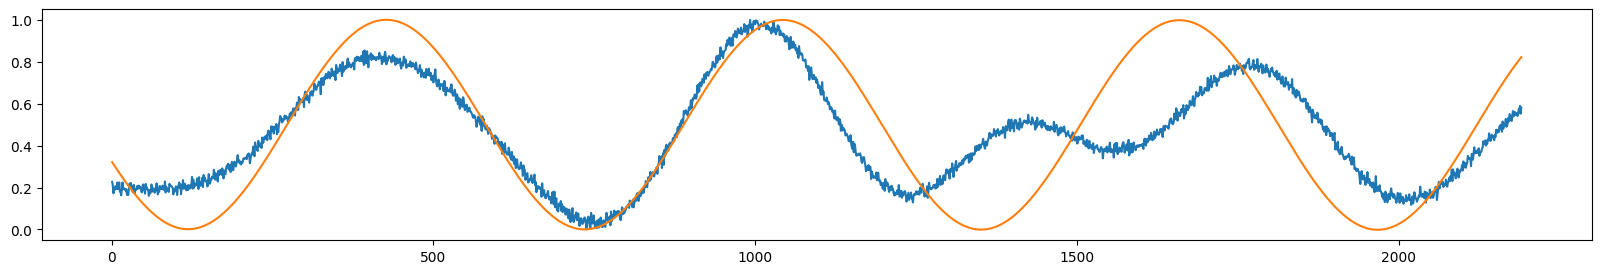

100%|██████████| 5/5 [00:00<00:00, 13.16it/s]


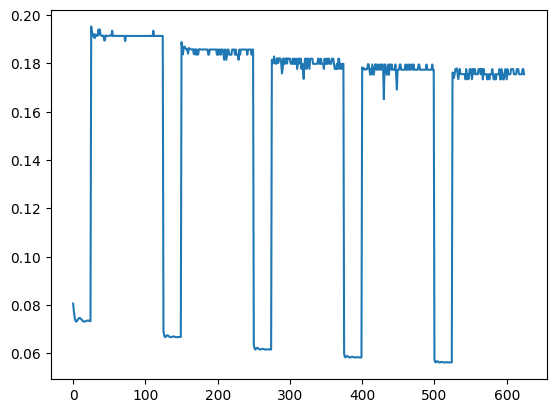

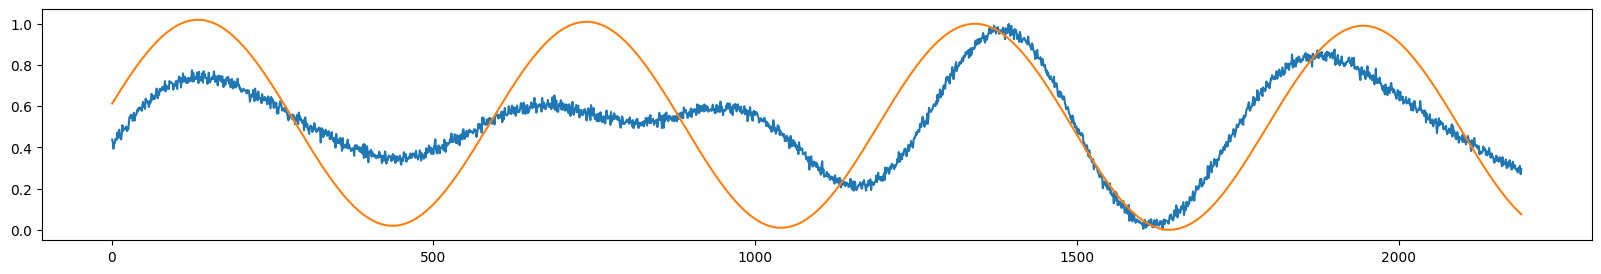

In [ ]:
for _ in range(10):
    sinenn = get_sinenn_wave(x, y, device)
    y_sinenn, middle_density = sinenn(torch.tensor(x, device=device))
    y_sinenn = y_sinenn.detach().cpu().numpy()
    plt.figure(figsize=(20, 3))
    plt.plot(x, y)
    plt.plot(x, y_sinenn)
    plt.show()
    y = normalize(y-y_sinenn)

# Old (FFT)

In [ ]:
1/0

ZeroDivisionError: division by zero

In [ ]:
class SineNN_FFT(torch.nn.Module):
    def __init__(self, y):
        super().__init__()
        device = y.device
        
        N = y.shape[0]
        Yf = torch.fft.fft(y)
        freqs = torch.fft.fftfreq(N)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1
        
        ampl0 = 2 * mag[peak_idx] / N
        phase0 = torch.angle(Yf[peak_idx])
        c0 = y.mean()
        
        self.a = torch.nn.Parameter(torch.tensor(ampl0, device=device))
        self.b = torch.nn.Parameter(torch.tensor(phase0, device=device))
        self.c = torch.nn.Parameter(torch.tensor(c0, device=device))
        
    def forward(self, x):
        return self.a * torch.sin(x + self.b) + self.c

In [ ]:
model = SineNN_FFT(y_train).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in tqdm.tqdm(range(1000)):
    optimizer.zero_grad()
    (loss := torch.mean((model(x_train) - y_train)**2)).backward()
    optimizer.step()

print(model.a.item(), model.b.item(), model.c.item())


x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
y_pred = model(x_test_tensor).detach().cpu().numpy()

TypeError: fft_fft(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [ ]:
class FFTPredictor:
    def __init__(self, y: torch.Tensor):
        """
        y: 1D tensor (float32) signal to analyze
        Computes amplitude, phase, and offset from FFT
        """
        N = y.shape[0]

        Yf = torch.fft.fft(y)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1  # skip DC

        self.ampl = 2 * mag[peak_idx] / N
        self.phase = torch.angle(Yf[peak_idx])
        self.offset = y.mean()

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: input tensor of positions
        Returns predicted sine values using FFT-estimated parameters
        """
        return self.ampl * torch.sin(x + self.phase) + self.offset

In [ ]:
torch.fft.fft(y_train_tensor)

tensor([831.6422+0.0000j, -16.7095+108.0916j, -18.8377+59.8880j,
         ..., -23.9169-49.2210j, -18.8377-59.8880j,
        -16.7095-108.0916j], device='cuda:0')

In [ ]:
device = "cuda"
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)

fft_pred = FFTPredictor(y_train_tensor)
y_pred = fft_pred.predict(x_test_tensor)

/tmp/ipykernel_17362/231372252.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
/tmp/ipykernel_17362/231372252.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)


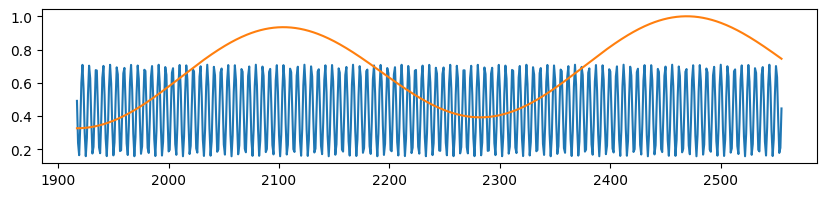

In [ ]:
plt.figure(figsize=(10, 2))
plt.plot(x_test, y_pred.cpu().detach().numpy())
plt.plot(x_test, y_test)